In [1]:
import sys
import os
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from warnings import filterwarnings
filterwarnings('ignore')

In [ ]:
df = pd.read_csv('/gibbs/arghavan/hp-results-pc/2026-09-29_hp_data.csv', index_col=None)
df.columns

Index(['d(nm)', 'D (A)', 'Volume (A^3)', '#confined waters',
       '#waters between plates', 'N/A^3', 'Enclosure Parameter',
       'N/V Ref. Bulk', '#neighbors', '#hbonds', '%hbond',
       'Average WW interaction energy', 'Average SW interaction energy',
       'Average Energy Per water (Kcal/mol)', 'Avg. Energy Ref. Bulk',
       'Delta E', 'Total Energy (Kcal/mol)',
       'Avg neighbor E (PAIRWISE) (Kcal/mol)',
       'Total Neighbor energy (Kcal/mol)', 'finite difference entropy',
       'gist total entropy', 'gist negTdSsix (kcal/mol)',
       'corrected  gist entropy', 'Solvent PMF', 'Leonnard Jones',
       'Total PMF'],
      dtype='object')

In [13]:
d = 0.92
N_nbr = df.loc[df['d(nm)'] == d, '#neighbors'].iloc[0]
N_nbr

np.float64(4.53303629)

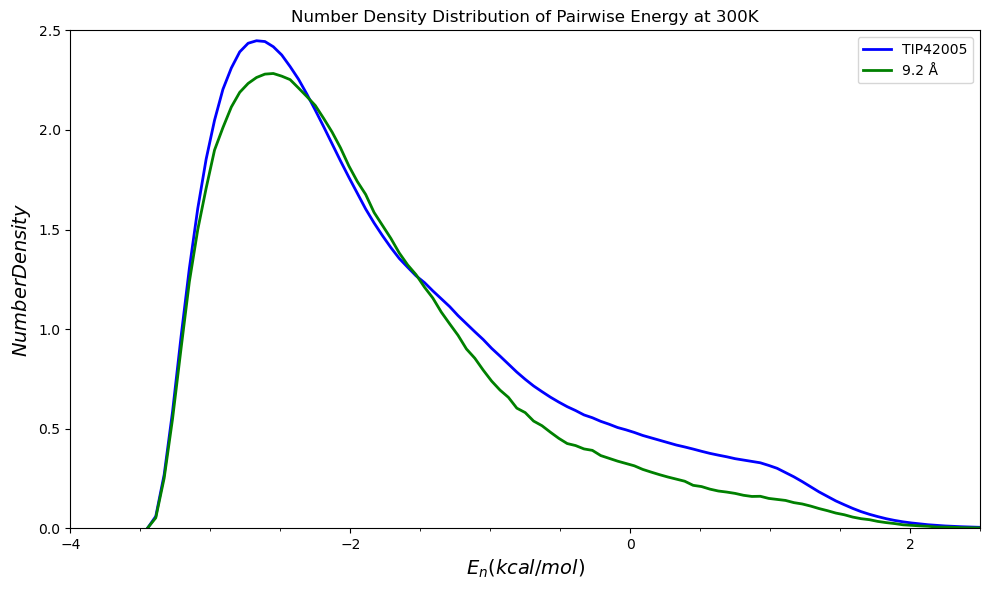

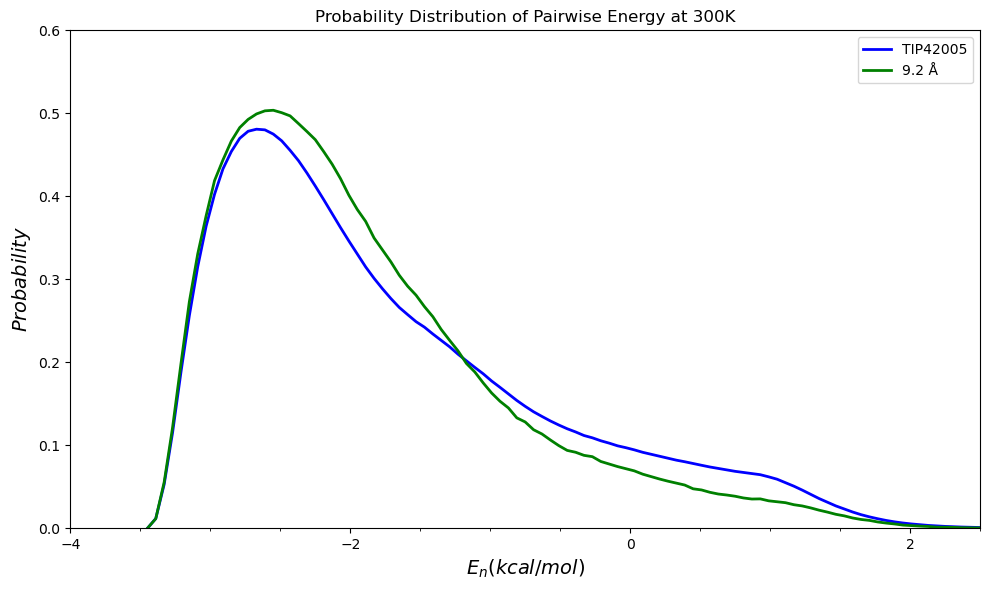

In [ ]:
output_path = f'/gibbs/arghavan/hp-results-pc/pairwise_energy_results/plots/'

# Bulk (TIP4P) .dat files, saved the same way
tip4p_prob_file = '/gibbs/arghavan/hp-results-pc/pairwise_energy_results/bulk_tip4p2005/prob_tip4p2005.dat'
tip4p_numDens_file = '/gibbs/arghavan/hp-results-pc/pairwise_energy_results/bulk_tip4p2005/numDens_tip4p2005.dat'


def load_dat(path):
    """Each file has two columns: bin_center, value."""
    data = np.loadtxt(path)
    return data[:, 0], data[:, 1]


os.makedirs(f"{output_path}/numberDensity/", exist_ok=True)
os.makedirs(f"{output_path}/probability/", exist_ok=True)

tip4p_bin_centers, prob_tip4p = load_dat(tip4p_prob_file)
_, rho_i_tip4p = load_dat(tip4p_numDens_file)

t = 300
ints = list(range(64, 151, 2))
distances_in_nm = [f"{d/100:.2f}" for d in ints]


for d in distances_in_nm:

    # Plate .dat files (bin_center, value), saved by the pairwise-energy script
    prob_file = f'/gibbs/arghavan/hp-results-pc/pairwise_energy_results/{t}K/{d}/prob_{d}.dat'
    numDens_file = f'/gibbs/arghavan/hp-results-pc/pairwise_energy_results/{t}K/{d}/numDens_{d}.dat'

    # --------------------------------------
    bin_centers, prob_plate = load_dat(prob_file)
    _, rho_i_plate = load_dat(numDens_file)


    # Plot 1: Number density
    plt.figure(figsize=(10, 6))
    plt.plot(tip4p_bin_centers, rho_i_tip4p, color='blue', linewidth=2, label="TIP42005")
    plt.plot(bin_centers, rho_i_plate, color='green', linewidth=2, label=f"{float(d)*10:.1f} Å")
    plt.title(f"Number Density Distribution of Pairwise Energy at {t}K")
    plt.xlabel(r"$E_n (kcal/mol)$", fontsize=14)
    plt.ylabel(r"$Number Density$", fontsize=14)
    plt.legend()
    plt.xlim(-4.0, 2.5)
    plt.ylim(0, 2.5)
    plt.xticks([-4.0, -2.0, 0.0, 2.0])
    plt.gca().xaxis.set_minor_locator(MultipleLocator(0.5))
    plt.tick_params(axis='x', which='minor', length=2)
    plt.tight_layout()
    plt.savefig(f"{output_path}/numberDensity/numDens_{d}.png", dpi=800)
    plt.close()

    # Plot 2: Probability density
    plt.figure(figsize=(10, 6))
    plt.plot(tip4p_bin_centers, prob_tip4p, color='blue', linewidth=2, label="TIP42005")
    plt.plot(bin_centers, prob_plate, color='green', linewidth=2, label=f"{float(d)*10:.1f} Å")
    plt.title(f"Probability Distribution of Pairwise Energy at {t}K")
    plt.xlabel(r"$E_n (kcal/mol)$", fontsize=14)
    plt.ylabel(r"$Probability$", fontsize=14)
    plt.legend()
    plt.xlim(-4.0, 2.5)
    plt.ylim(0, 0.6)
    plt.xticks([-4.0, -2.0, 0.0, 2.0])
    plt.gca().xaxis.set_minor_locator(MultipleLocator(0.5))
    plt.tick_params(axis='x', which='minor', length=2)
    plt.tight_layout()
    plt.savefig(f"{output_path}/probability/probDens_{d}.png", dpi=800)
    plt.close()

In [ ]:


t = 300
d = 0.92





# tip4p_mean_nbr_path = '/gibbs/arghavan/tip4p_bulk_simulation/all_frame_mean_neighbours.pkl'

# mean_nbr_path = f'/gibbs/arghavan/counting_hbonds_between_graphite_walls/hbond_outputs/{t}K/{d}/all_frame_mean_neighbours.pkl'

# e_file = f'/gibbs/arghavan/pair_energy/results_pair_energy/{t}K/{t}K_{d}/E_{t}K_{d}.dx'
# tip4p_e_file = '/gibbs/arghavan/pair_energy/results_pair_energy/wholeBox_E_tip4p.dx'

# mean_nbr = df['#neighbors']
N_nbr = df.loc[df['d(nm)'] == d, '#neighbors'].iloc[0]

os.makedirs(f"{output_path}/numberDensity/", exist_ok=True)
os.makedirs(f"{output_path}/probability/", exist_ok=True)

# def load_dx_file(dx_file):
#     with open(dx_file, "r") as f:
#         energies = f.readlines()[2:]
#         return np.array([float(value) for e in energies for value in e.split()])
    
# def load_mean_nbr(path):
#     mean_nbr = []
#     with open(path, 'rb') as f:
#         while True:
#             try:
#                 mean_nbr.append(pickle.load(f))
#             except EOFError:
#                 break
#     return mean_nbr[0][0]

# --------------------------------------
N_nbr = load_mean_nbr(mean_nbr_path)
energies = load_dx_file(e_file)

tip4p_N_nbr = 5.09
tip4p_energies = load_dx_file(tip4p_e_file)


bin_width = 0.06

global_min_E = min(np.min(tip4p_energies), np.min(energies))
global_max_E = max(np.max(tip4p_energies), np.max(energies))

bins = np.arange(np.floor(global_min_E / bin_width) * bin_width,
                 np.ceil(global_max_E / bin_width) * bin_width + bin_width, bin_width)


tip4p_counts, edges = np.histogram(tip4p_energies, bins=bins)
plate_counts, _ = np.histogram(energies, bins=bins)

prob_tip4p = tip4p_counts / (bin_width * np.sum(tip4p_counts))
prob_plate = plate_counts / (bin_width * np.sum(plate_counts))

rho_i_tip4p = prob_tip4p * tip4p_N_nbr
rho_i_plate = prob_plate * N_nbr

bin_centers = edges[:-1] + bin_width / 2



# Plot 1: Number density
plt.figure(figsize=(8, 6))
plt.plot(bin_centers, rho_i_tip4p, color='blue', linewidth=2, label="TIP4EW")
plt.plot(bin_centers, rho_i_plate, color='green', linewidth=2, label=f"{float(d)*10:.1f} Å")
plt.title(f"Number Density Distribution of Pairwise Energy at {t} K")
plt.xlabel(r"$E_n (kcal/mol)$", fontsize=14)
plt.ylabel(r"$\rho_i(E_n)$", fontsize=14)
plt.legend()
plt.xlim(-4.0, 2.5)
plt.ylim(0, 2.5)
plt.xticks([-4.0, -2.0, 0.0, 2.0])
plt.gca().xaxis.set_minor_locator(MultipleLocator(0.5))
plt.tick_params(axis='x', which='minor', length=2)
plt.tight_layout()
plt.savefig(f"{output_path}/numberDensity/numDens_{t}K_{d}.png", dpi=300)
plt.close()

# Plot 2: Probability density
plt.figure(figsize=(8, 6))
plt.plot(bin_centers, prob_tip4p, color='blue', linewidth=2, label="TIP4EW")
plt.plot(bin_centers, prob_plate, color='green', linewidth=2, label=f"{float(d)*10:.1f} Å")
plt.title(f"Probability Distribution of Pairwise Energy at {t} K")
plt.xlabel(r"$E_n (kcal/mol)$", fontsize=14)
plt.ylabel(r"$\rho_i(E_n)/N_{{nbr}}$", fontsize=14)
plt.legend()
plt.xlim(-4.0, 2.5)
plt.ylim(0, 0.6)
plt.xticks([-4.0, -2.0, 0.0, 2.0])
plt.gca().xaxis.set_minor_locator(MultipleLocator(0.5))
plt.tick_params(axis='x', which='minor', length=2)
plt.tight_layout()
plt.savefig(f"{output_path}/probability/probDens_{t}K_{d}.png", dpi=300)
plt.close()
